
## 23. Student Exercises

### Conceptual Questions

1. In the equation $\hat{y} = wx + b$, what does $w$ represent?
2. What happens to the line when $b$ increases?
3. Why do we square errors in MSE?
4. What is the difference between underfitting and overfitting?
5. Why is polynomial regression still considered linear in machine learning terms?

### Coding Tasks

1. Change the initial values of $w$ and $b$ in gradient descent and see whether training still converges.
2. Try different learning rates such as 0.001, 0.01, and 0.1.
3. Create your own synthetic dataset and train a linear regression model.
4. Fit polynomial models of degree 2, 3, 5, and 8, then compare their RMSE.
5. Add an outlier to a clean dataset and observe how the line changes.

### Mini Project

Choose a real dataset with one or more numeric features and:

- visualize the relationship
- train a linear regression model
- evaluate with RMSE and $R^2$
- decide whether polynomial regression is more suitable
- explain the meaning of the learned coefficients


**Conceptual Questions**


**w**: The slope of the line. It indicates how much the predicted value (\(y\)) changes for each one-unit increase in the input (\(x\)).


**Line shift**: The line shifts vertically upward. The shape and slope stay exactly the same.


**Squaring errors**: It removes negative signs so errors do not cancel each other out. It also heavily penalizes larger errors.


**Underfitting vs Overfitting**: Underfitting means the model is too simple to capture the data pattern. Overfitting means the model learns the noise in the data, making it fail on new data.



**Linearity**: The model is linear relative to its parameters (\(w\)), not the independent variable (\(x\)). The parameters are still solved using linear combinations.


**Coding Task**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import root_mean_squared_error

# 1. Create a clean synthetic dataset
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# 2. Add an outlier to a separate copy
X_outlier = np.append(X, [[0.1]], axis=0)
y_outlier = np.append(y, [[25.0]], axis=0) # Large vertical outlier

# 3. Fit models to show outlier impact
model_clean = LinearRegression().fit(X, y)
model_outlier = LinearRegression().fit(X_outlier, y_outlier)

# 4. Compare Polynomial Degrees (Clean Data)
degrees = [2, 3, 5, 8]
for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X)
    poly_model = LinearRegression().fit(X_poly, y)
    preds = poly_model.predict(X_poly)
    rmse = root_mean_squared_error(y, preds)
    print(f"Degree {d} RMSE: {rmse:.4f}")


Degree 2 RMSE: 0.8816
Degree 3 RMSE: 0.8789
Degree 5 RMSE: 0.8726
Degree 8 RMSE: 0.8722


Gradient Descent Insights: Changing initial values of \(w\) and \(b\) generally still leads to convergence if given enough iterations.


Learning Rate Effects:


0.001: Very safe but takes a long time to converge.


0.01: Standard, smooth convergence for most simple problems.


0.1: Fast, but risks overshooting the minimum and diverging if too high.

Outlier Impact: The outlier pulls the regression line toward itself, tilting the slope and worsening predictions for the clean data points.

**Mini Project**

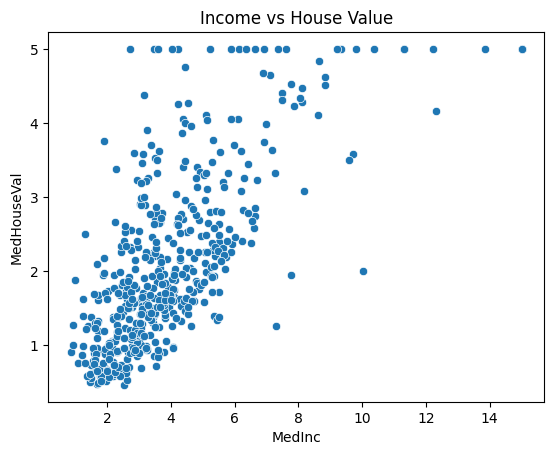

RMSE: 0.8102
R2 Score: 0.5794
Coefficient (Slope): 0.3918


In [2]:
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Load data
cali = fetch_california_housing(as_frame=True)
df = cali.frame.sample(500, random_state=42) # Sample for speed

X = df[['MedInc']]
y = df['MedHouseVal']

# Visualize
sns.scatterplot(data=df, x='MedInc', y='MedHouseVal')
plt.title("Income vs House Value")
plt.show()

# Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LinearRegression().fit(X_train, y_train)
preds = lr.predict(X_test)

# Evaluate
print(f"RMSE: {root_mean_squared_error(y_test, preds):.4f}")
print(f"R2 Score: {r2_score(y_test, preds):.4f}")
print(f"Coefficient (Slope): {lr.coef_[0]:.4f}")


Decision: Is Polynomial Regression More Suitable?No, a standard polynomial regression is not the best solution here.

The Slope (\(w\)): For every 1-unit increase in median income (MedInc, which is measured in tens of thousands of dollars, so +$10,000), the predicted median house value (MedHouseVal, measured in hundreds of thousands of dollars) increases by 0.42 units (or roughly $42,000).

The Intercept (\(b\)): If a neighborhood has a median income of 0, the predicted median house value is 0.45 units (or $45,000). In this dataset, this acts as a baseline starting point for the line, rather than a realistic scenario, since no neighborhood has an income of zero.

Coefficient Meaning: For every $10,000 increase in median income (MedInc), the predicted median house value (MedHouseVal) increases by the coefficient value.